# Features Description for Data:


*   `start_point`, `end_point`: Districts of Jakarta from which and to which the trip is being made (for example, Central Jakarta → North Jakarta).
*   `time_of_day`: Time of the day.
*   `day_of_week`: Day of the week.
*   `traffic_condition`: Traffic conditions during the trip (congestions etc.).
*   `event_count`: Number of events occurring near the route.
*   `is_holiday`: Whether the trip takes place on the same day as a public holiday.
*   `weather`: Weather conditions on the day of the trip.
*   `population_density`: Population density in the districts along the route.
*   `vehicle_density`: Vehicle density in the districts along the route.
*   `public_transport_availability`: Availability of public transport along the route.
*   `historical_delay_factor`: Total travel delay on the day of the trip.
*   `travel_time`: Actual travel time (target-feature).

# Import Library yang dibutuhkan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# Load Data

In [ ]:
df = pd.read_csv('train_sample.csv')
df.head()

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor,travel_time
0,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),day,Sunday,NaN,9,1,NaN,high,NaN,1,0.878909,26.907612
1,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),morning,Thursday,NaN,7,1,medium,high,NaN,1,1.081668,27.489129
2,Central Jakarta (Jakarta Pusat),East Jakarta (Jakarta Timur),morning,Thursday,NaN,7,0,medium,low,NaN,2,1.192379,27.228978
3,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),morning,Friday,10.0,9,0,medium,high,fog,1,0.833348,33.943970
4,Central Jakarta (Jakarta Pusat),West Jakarta (Jakarta Barat),day,Tuesday,NaN,7,0,medium,high,rain,2,0.966819,20.603115


In [ ]:
df.isna().sum()

,0
start_point,0
end_point,0
time_of_day,0
day_of_week,0
traffic_condition,14401
event_count,0
is_holiday,0
vehicle_density,14378
population_density,14448
weather,14429


### Cek Outlier di Target

<Axes: xlabel='travel_time'>

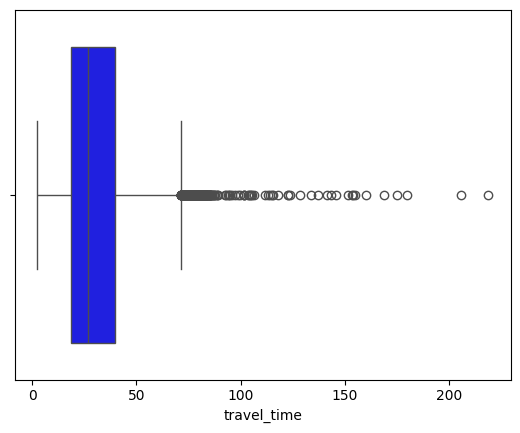

In [ ]:
sns.boxplot(df,x="travel_time", color = "b")

<Axes: xlabel='travel_time', ylabel='Count'>

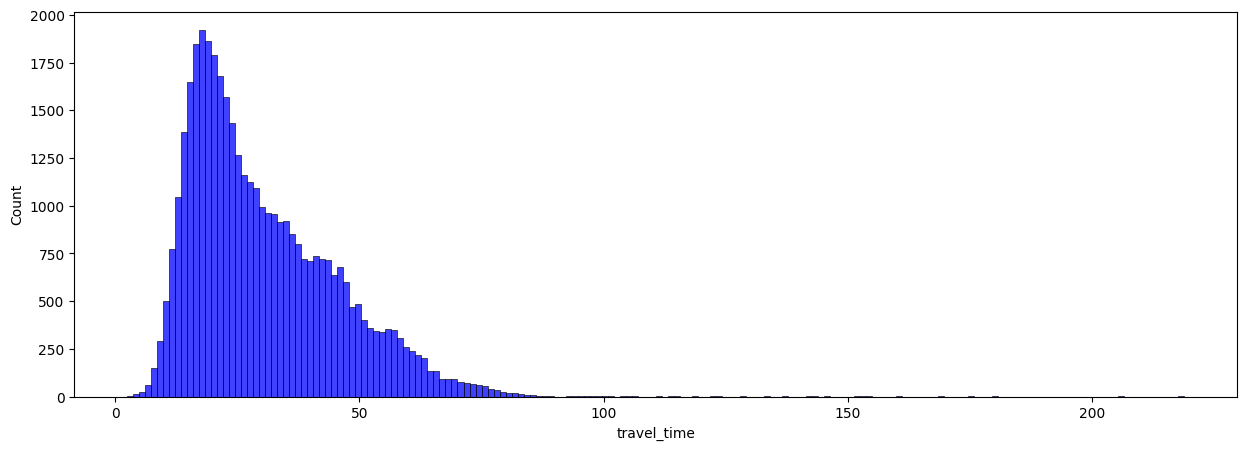

In [ ]:
plt.figure(figsize = (15,5))
sns.histplot(df,x="travel_time", color = "b")

### Cek Correlation

In [ ]:
df.corr(numeric_only=True)["travel_time"]

,travel_time
traffic_condition,-0.001405
event_count,-0.009502
is_holiday,-0.000366
public_transport_availability,0.246958
historical_delay_factor,0.052816
travel_time,1.000000


<Axes: >

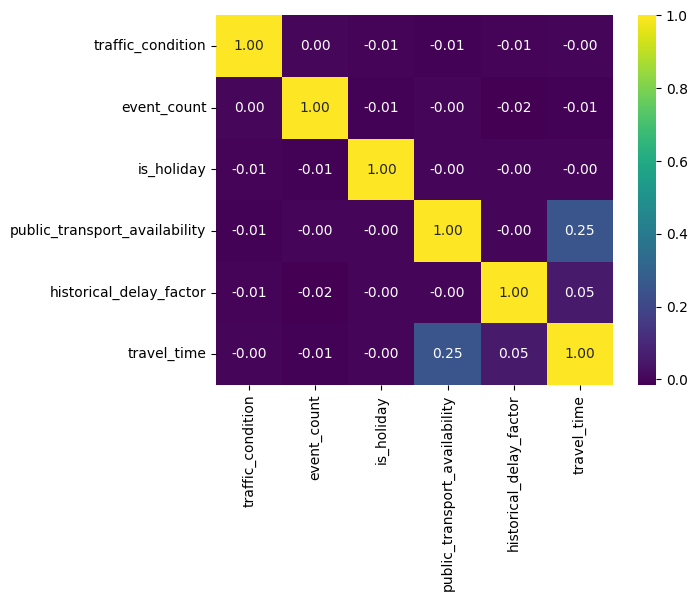

In [ ]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f")

## Kategorik vs Target


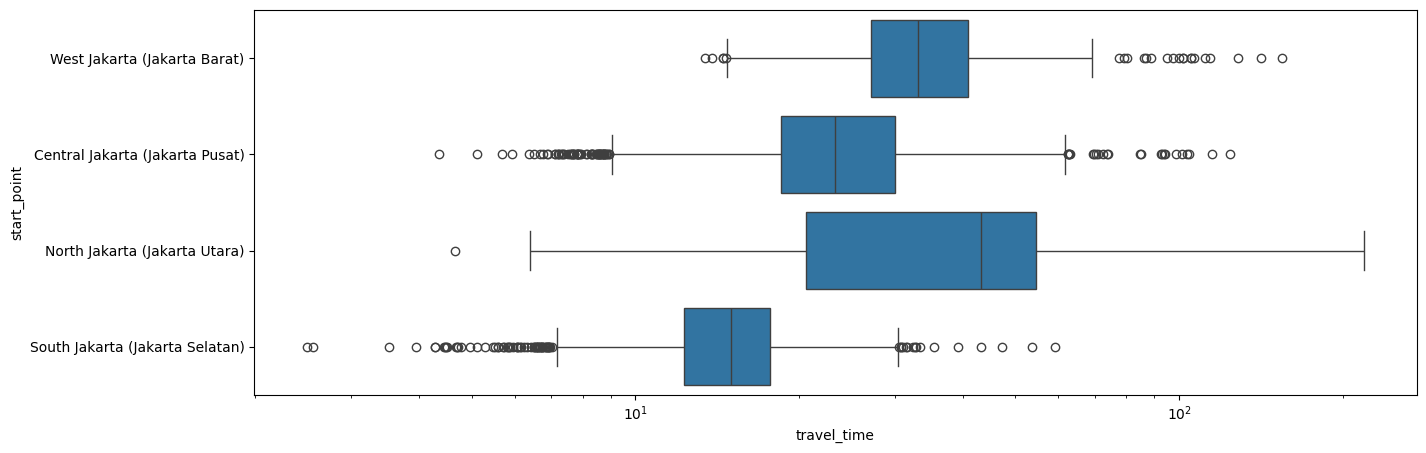

In [ ]:
plt.figure(figsize=(15, 5))
sns.boxplot(df, x="travel_time", y="start_point", orient="h", log_scale=(True, False));

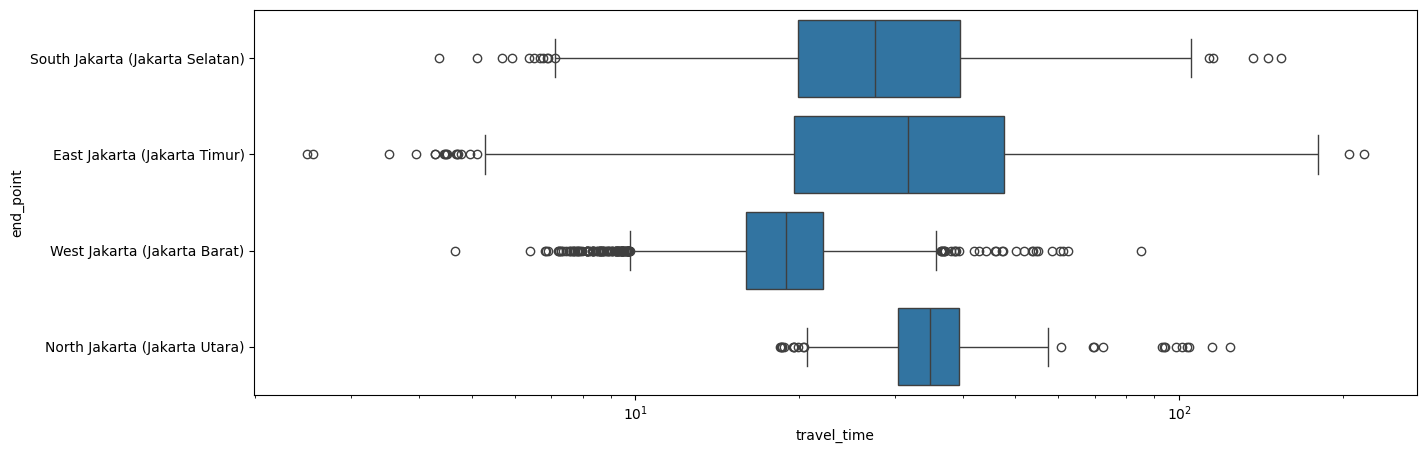

In [ ]:
plt.figure(figsize=(15, 5))
sns.boxplot(df, x="travel_time", y="end_point", orient="h", log_scale=(True, False));

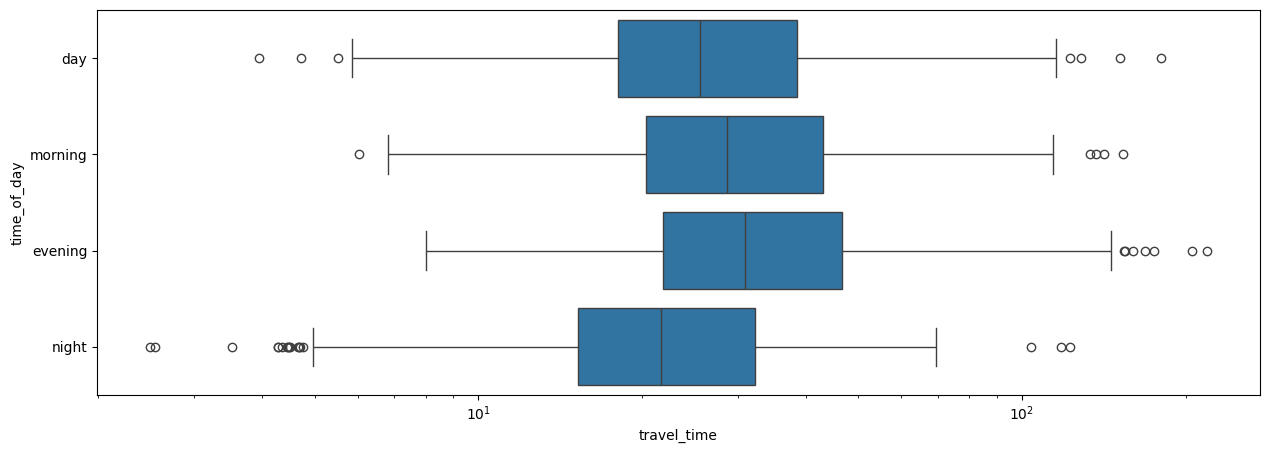

In [ ]:
plt.figure(figsize=(15, 5))
sns.boxplot(df, x="travel_time", y="time_of_day", orient="h", log_scale=(True, False));

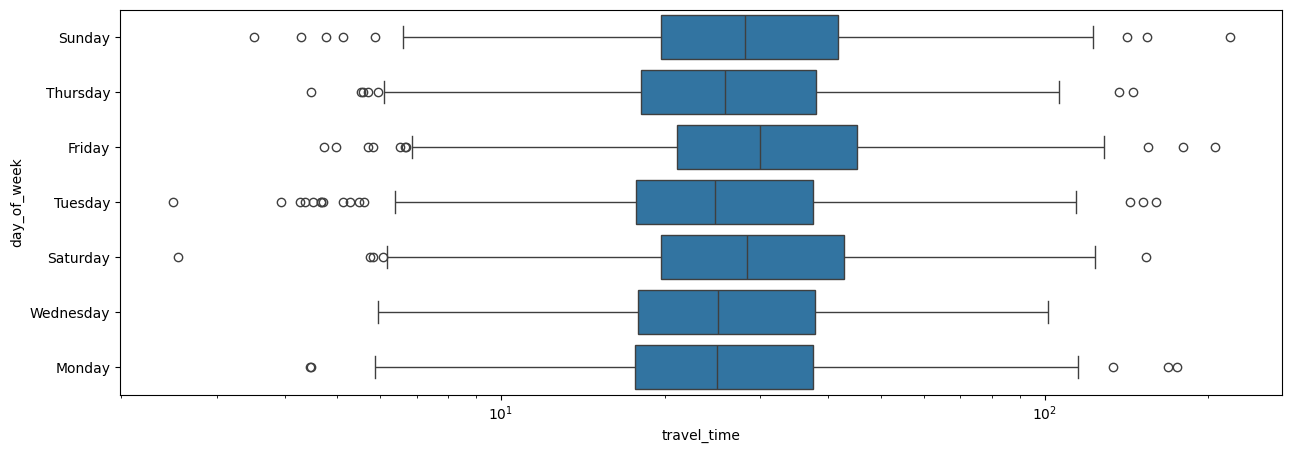

In [ ]:
plt.figure(figsize=(15, 5))
sns.boxplot(df, x="travel_time", y="day_of_week", orient="h", log_scale=(True, False));

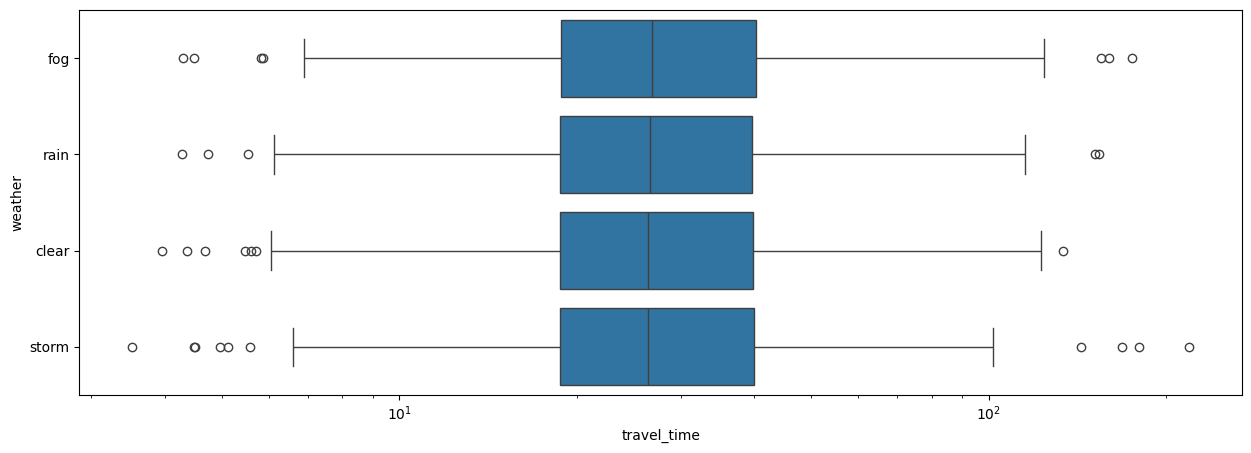

In [ ]:
plt.figure(figsize=(15, 5))
sns.boxplot(df, x="travel_time", y="weather", orient="h", log_scale=(True, False));

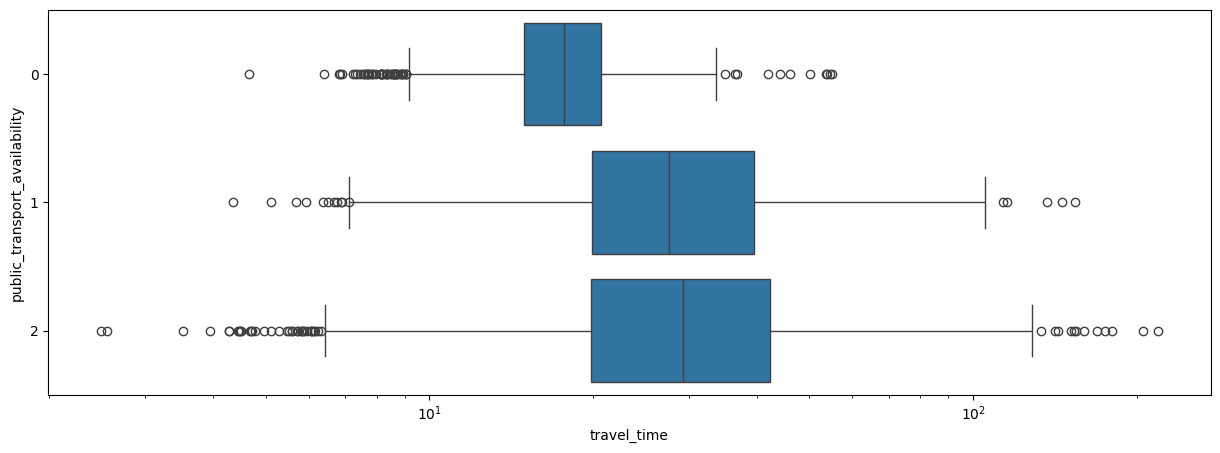

In [ ]:
plt.figure(figsize=(15, 5))
sns.boxplot(df, x="travel_time", y="public_transport_availability", orient="h", log_scale=(True, False));

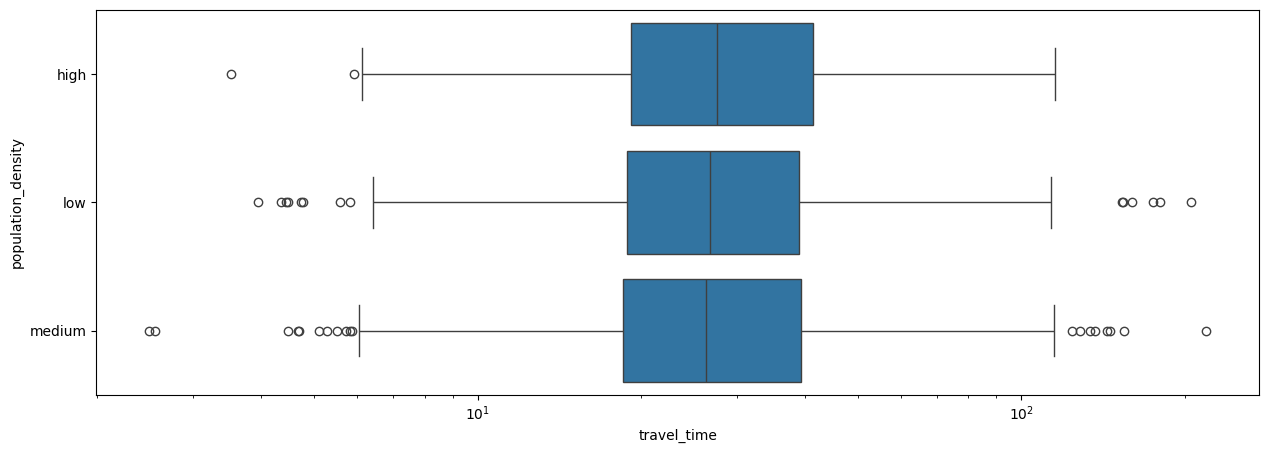

In [ ]:
plt.figure(figsize=(15, 5))
sns.boxplot(df, x="travel_time", y="population_density", orient="h", log_scale=(True, False));

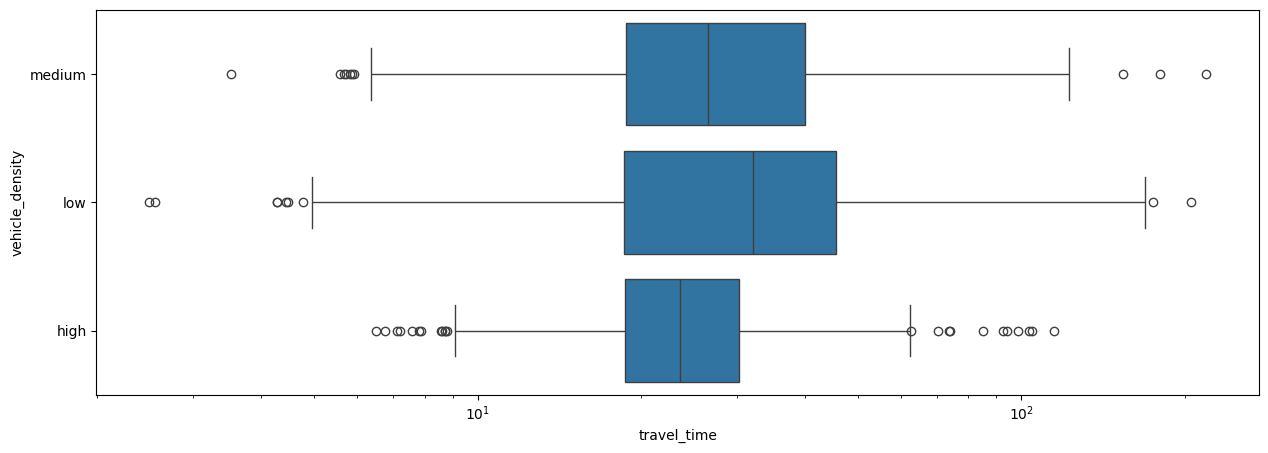

In [ ]:
plt.figure(figsize=(15, 5))
sns.boxplot(df, x="travel_time", y="vehicle_density", orient="h", log_scale=(True, False));

## Kesimpulan

fitur yang akan digunakan:
* numeric : public_transport_availability
* categoric : start_point, end_point, day_of_week, time_of_day, vehicle_density




# Dataset splitting

In [ ]:
X = df.drop(columns="travel_time") #semua kolom selain kolom price, jangan di inplace
y = df.travel_time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
X_train.shape, X_test.shape

((32000, 12), (8000, 12))

# Preprocessing Pipeline

In [ ]:
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy='median')),
    ("scale", RobustScaler()),
])
numeric_pipeline

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scale', RobustScaler())])

In [ ]:
categoric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy='most_frequent')),
    ("encode", OneHotEncoder()) #OneHotEncoder(drop="first", handle_unknown="ignore")
])
categoric_pipeline

Pipeline(steps=[('impute', SimpleImputer(strategy='most_frequent')),
                ('encode', OneHotEncoder())])

In [ ]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, ["public_transport_availability"]),
    ("categoric", categoric_pipeline, ["start_point",	"end_point", "time_of_day", "day_of_week", "vehicle_density"])
])
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', RobustScaler())]),
                                 ['public_transport_availability']),
                                ('categoric',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode', OneHotEncoder())]),
                                 ['start_point', 'end_point', 'time_of_day',
                                  'day_of_week', 'vehicle_density'])])

# Training

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [ ]:
model = Pipeline([
    ("prep", preprocessor),
    ("algo", LinearRegression(fit_intercept=False))
])

model.fit(X_train, y_train)
print(f"R2 Train: {model.score(X_train, y_train):.4f}")
print(f"R2 Test : {model.score(X_test, y_test):.4f}")

R2 Train: 0.8761
R2 Test : 0.8856


# Evaluasi

### Actual vs Prediction Plot

In [ ]:
from sklearn.metrics import PredictionErrorDisplay

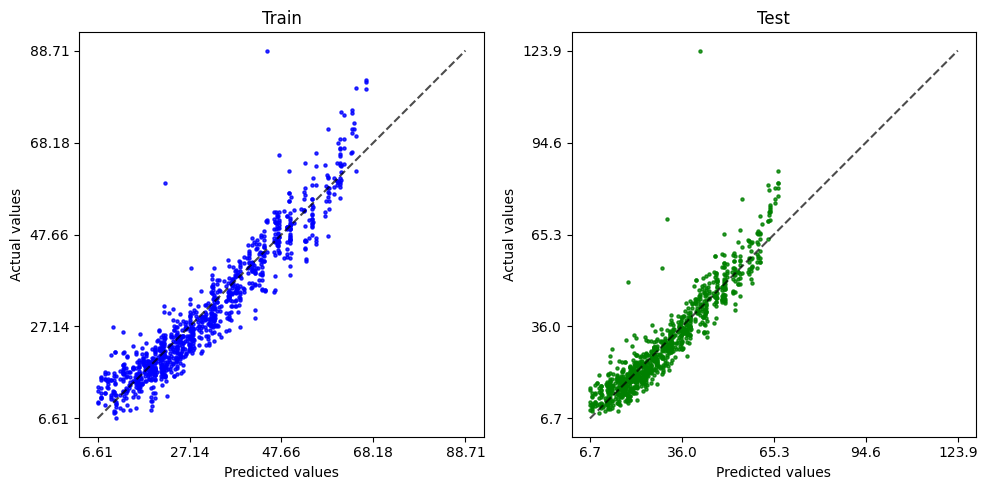

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
PredictionErrorDisplay.from_estimator(model, X_train, y_train, kind="actual_vs_predicted", scatter_kwargs={"c": "b", "s": 5}, ax=ax[0])
ax[0].set_title("Train")
ax[0].set_aspect("equal")

PredictionErrorDisplay.from_estimator(model, X_test, y_test, kind="actual_vs_predicted", scatter_kwargs={"c": "g", "s": 5}, ax=ax[1])
ax[1].set_title("Test")
ax[1].set_aspect("equal")

fig.tight_layout()

# Submit Prediksi

In [ ]:
df_submit = pd.read_csv("test_sample.csv")

In [ ]:
pd.DataFrame(model.predict(df_submit)).to_csv('my_submission_2.csv')